#### Libs and configs

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

project_dir = Path.cwd().parent

if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))

In [3]:
import pandas as pd
import numpy as np

from src.preprocessing.match_samples import propensity_score_match

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, chi2_contingency

In [4]:
custom_params = {'axes.spines.right': False, 'axes.spines.top': False}
sns.set_theme(style='ticks', rc=custom_params)

#### Data

In [5]:
info = pd.read_csv('../data/demographics/info.csv', sep=';')

In [6]:
info.shape

(2645, 8)

In [7]:
info.sample(n=10)

,dataset,id,age,sex,site,scanner,group,label
1131,READISCA,769650_V2.nii.gz,42.0,M,S6,3T,unhealthy,useful
93,IXI,sub-110_T1w.nii.gz,37.0,M,Guys Hospital,1.5T,healthy,useful
213,IXI,sub-249_T1w.nii.gz,68.0,M,Guys Hospital,1.5T,healthy,useful
2622,TRACK-FA,TRACKFA_MCG001_MR01.nii.gz,25.0,M,MCG,3T,healthy,useful
121,IXI,sub-142_T1w.nii.gz,48.0,F,Guys Hospital,1.5T,healthy,useful
580,ADNI,020_S_1288_MPRAGE_2007-03-13_I44672.nii.gz,60.0,M,20,3T,healthy,useful
80,IXI,sub-097_T1w.nii.gz,35.0,F,Hammersmith Hospital,3T,healthy,not-useful
1087,READISCA,689576_V1.nii.gz,53.0,M,S4,3T,unhealthy,useful
1310,PPMI,3059,83.0,M,13,1.5T,unhealthy,useful
1700,PPMI,3955,54.0,M,21,1.5T,healthy,useful


#### Matching with Propensity Score Matching (PSM)

In [17]:
matched_df = propensity_score_match(
    df=info,
    covariates=['dataset', 'age', 'sex', 'site', 'scanner', 'group'],
    target_col='label',
    positive_class='not-useful',
    ratio=2,
    caliper=0.05,
    random_state=42,
    verbose=True
)

[INFO] not-useful available: 205.
[INFO] useful available: 2440.
[INFO] Fitting logistic regression.
[INFO] Calculating propensity scores.
[INFO] Fitting KNN.
[INFO] Matching cases and controls.
[INFO] useful selected: 298
[INFO] Total images: 503


In [18]:
matched_df.shape

(503, 8)

##### Evaluation

Final composition

In [19]:
print('Total images:', len(matched_df))
print('Images per label:', matched_df.label.value_counts())

Total images: 503
Images per label: label
useful        298
not-useful    205
Name: count, dtype: int64


Age descriptive stats

In [21]:
(
    matched_df
    .groupby('label')
    .age
    .agg(
        n='count',
        mean='mean',
        median='median',
        std='std',
        q1=lambda values: values.quantile(0.25),
        q3=lambda values: values.quantile(0.75)
    )
    .round(2)
)

,n,mean,median,std,q1,q3
label,,,,,,
not-useful,205,56.66,62.0,19.81,45.0,71.0
useful,298,55.95,60.0,18.24,46.0,69.0


SMD and Mann-Whitney for age

In [23]:
useful_age = matched_df.query("label == 'useful'").age
not_useful_age = matched_df.query("label == 'not-useful'").age

pooled_std = np.sqrt((useful_age.var() + not_useful_age.var()) / 2)
age_smd = (useful_age.mean() - not_useful_age.mean()) / pooled_std

In [24]:
mannwhitney_result = mannwhitneyu(
    useful_age,
    not_useful_age,
    alternative='two-sided'
)

In [25]:
print('SMD:', age_smd)
print('Mann-Whitney p-value:', mannwhitney_result.pvalue)

# Simple interpretation:
if abs(age_smd) < 0.10:
    print('Age is well balanced.')
else:
    print('Age presents a possible imbalance.')

SMD: -0.037232417337532894
Mann-Whitney p-value: 0.32596388291819367
Age is well balanced.


Age boxplot

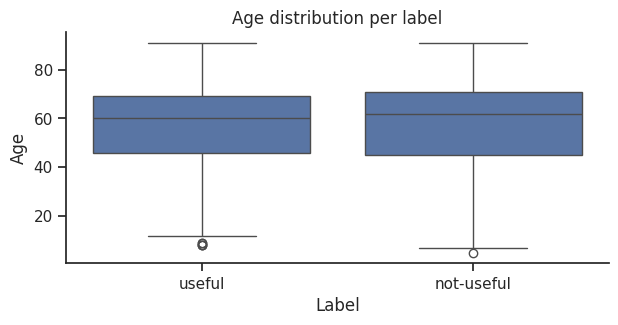

In [26]:
plt.figure(figsize=(7, 3))
sns.boxplot(
    data=matched_df,
    x='label',
    y='age'
)
plt.title('Age distribution per label')
plt.xlabel('Label')
plt.ylabel('Age')
plt.show()

Age dist

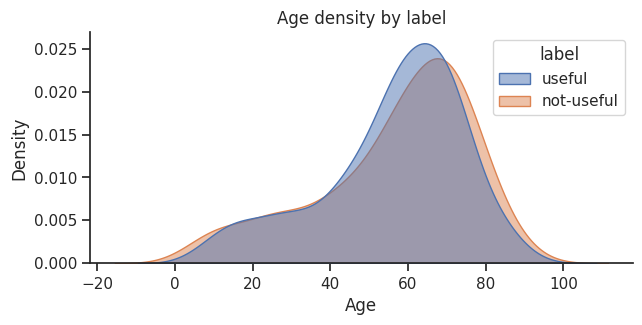

In [27]:
plt.figure(figsize=(7, 3))
sns.kdeplot(
    x='age',
    hue='label',
    fill=True,
    common_norm=False,
    alpha=0.5,
    data=matched_df
)
plt.title('Age density by label')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

Proportion for categoricals

In [28]:
categorical_columns = ['dataset', 'sex', 'site', 'scanner', 'group']

In [29]:
for column in categorical_columns:
    print('Distribution of', column)

    proportions = (
        pd.crosstab(
            matched_df[column],
            matched_df['label'],
            normalize='columns'
        )
        * 100
    )

    display(proportions.round(2))

Distribution of dataset


label,not-useful,useful
dataset,,
ADNI,10.73,9.06
IXI,20.49,23.83
PD-Campinas,6.83,9.06
PPMI,52.68,48.66
READISCA,1.46,1.01
TRACK-FA,7.80,8.39


Distribution of sex


label,not-useful,useful
sex,,
F,35.61,34.9
M,64.39,65.1


Distribution of site


label,not-useful,useful
site,,
116,0.49,1.34
12,0.00,0.67
126,0.49,0.67
127,0.49,0.34
13,0.98,1.01
131,0.98,0.67
133,2.44,2.01
14,2.44,4.03
16,0.98,1.01


Distribution of scanner


label,not-useful,useful
scanner,,
1.5T,40.49,32.55
3T,59.51,67.45


Distribution of group


label,not-useful,useful
group,,
healthy,35.12,34.9
unhealthy,64.88,65.1


Chi-squared test for categoricals

In [30]:
categorical_tests = []

for column in categorical_columns:
    contingency_table = pd.crosstab(
        matched_df[column], matched_df['label'])

    # No test if only one category.
    if contingency_table.shape[0] <= 1:
        categorical_tests.append({
            'variable': column,
            'test': 'no aplicable',
            'p_value': np.nan
        })

        continue

    chi_squared_result = chi2_contingency(contingency_table)

    categorical_tests.append({
        'variable': column,
        'test': 'chi-squared',
        'p_value': chi_squared_result.pvalue
    })

In [31]:
categorical_tests = pd.DataFrame(categorical_tests)
categorical_tests['p_value'] = categorical_tests['p_value'].round(4)

In [32]:
categorical_tests

,variable,test,p_value
0,dataset,chi-squared,0.7994
1,sex,chi-squared,0.9450
2,site,chi-squared,0.6402
3,scanner,chi-squared,0.0836
4,group,chi-squared,1.0000


Categorical plots

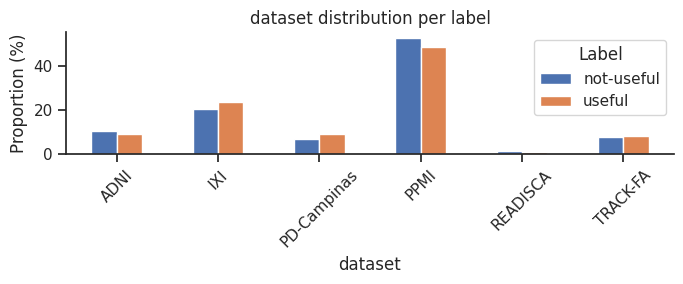

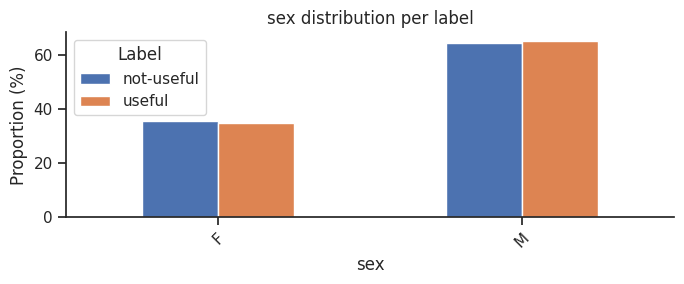

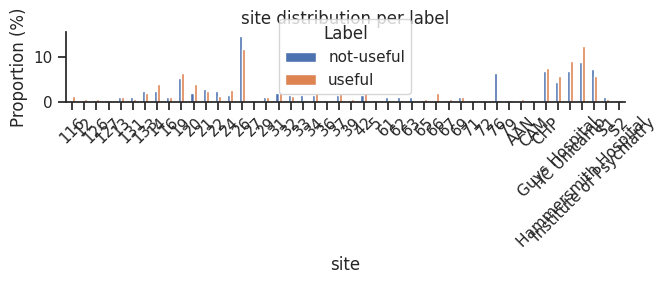

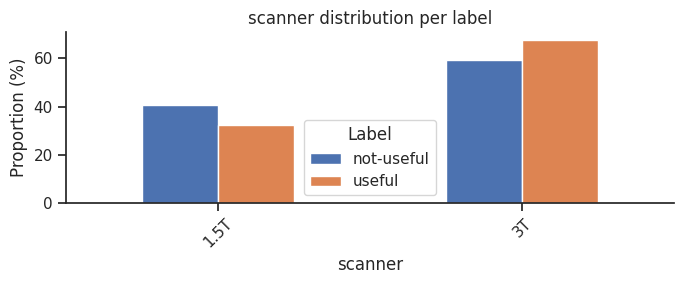

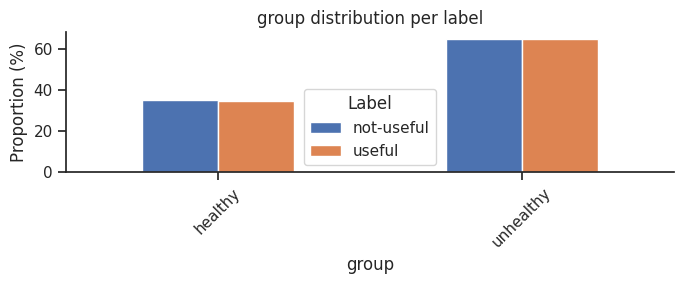

In [33]:
for column in categorical_columns:
    proportions = (
        pd.crosstab(
            matched_df[column],
            matched_df['label'],
            normalize='columns',
        )
        * 100
    )

    proportions.plot(
        kind="bar",
        figsize=(7, 3),
    )

    plt.title(f"{column} distribution per label")
    plt.xlabel(column)
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=45)
    plt.legend(title='Label')
    plt.tight_layout()
    plt.show()

##### Saving PSM matched dataset

In [34]:
matched_df.to_csv('../data/demographics/matched_psm_info.csv', sep=';', index=False)

#### Matching with Coarsened Exact Matching (CEM)

##### Evaluation

##### Saving CEM matched dataset